# Feature Engineering 
- use: travel personas, using k means to try and find the type of traveller i am on different days

Notes:
- curse of dimensionality: if i put too many features relating to one topic, the rest will be ignored in favor of the feature heavy tiopic
- consider what is important: look into PCA?
- remember kmeans if sensitive to scaling of values - use StandardScaler

### Imports

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import plotly.express as px
import plotly.graph_objects as go
import datetime

import json

from transformers import pipeline
from sentence_transformers import SentenceTransformer, util

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

NEED TO DO: install plotly, matplotlib, seaborn, sentence_transformers into environment

In [3]:
# pd.set_option('display.max_columns', None)

### Variables

In [4]:
hours_in_a_day = 24

In [5]:
regions = {
    'South America': ['Colombia','Ecuador','Peru','Bolivia','Brasil'],
    'Central America': ['Guatemala','Honduras','Nicaragua','El Salvador'],
    'Southern Africa': ['South Africa','Malawi','Mozambique','Eswatini','Lesotho']
}

In [6]:
base_currency = ['CAD']

In [7]:
countries = {
    'Colombia' : {
        'color': '#EFCA08',
        'currency': ['COP']
    },
    'Ecuador' : {
        'color': '#FF9000',
        'currency': ['USD']
    },
    'Peru' : {
        'color': '#DB5461',
        'currency': ['PEN']
    },
    'Bolivia' : {
        'color': '#A4243B',
        'currency': ['BOB']
    },
    'Brasil' : {
        'color': '#94BFA7',
        'currency': ['BRL']
    },
    'Guatemala' : {
        'color': '#86A5D9',
        'currency': ['GTQ','USD']
    },
    'Honduras' : {
        'color': '#0B3954',
        'currency': ['HNL','USD']
    },
    'Nicaragua' : {
        'color': '#57C4E5',
        'currency': ['NIO','USD']
    },
    'El Salvador': {
        'color': '#273043',
        'currency': ['USD']
    },
    'South Africa': {
        'color': '#D4E09B',
        'currency': ['ZAR']
    },
    'Malawi': {
        'color': '#D72638',
        'currency': ['MK','BMK']
    },
    'Mozambique': {
        'color': '#2D5C1E',
        'currency': ['MZN']
    },
    'Eswatini': {
        'color': '#AFA3B8',
        'currency': ['ZAR']
    },
    'Lesotho': {
        'color': '#8EF9F3',
        'currency': ['ZAR']
    }
}

In [8]:
transport_types = {
    'hitchhiking': {
        'values': ['hitchhiking'],
        'comfort_mapping': 1
    },
    'self': {
        'values': ['car', 'car share'],
        'comfort_mapping': 5
    },
    'bus': {
        'values': ['bus'],
        'comfort_mapping': 3
    },
    'tourist': {
        'values': ['van', 'truck', 'flight', 'teleferico', 'jeep', 'boat', 'shuttle'],
        'comfort_mapping': 4
    },
    'local': {
        'values': ['chicken bus', 'mini bus', 'chapa', 'kombi', 'collectivo', 'train'],
        'comfort_mapping': 2
    }
}

# 0 value is stationary

In [9]:
# using duplicated() to identify non novel adventures, and then have to flip the boolean logic
novelty_mapping = {False: 1, True: 0}

In [10]:
activity_mapping = {
    'sport': ['jiu jitsu', 'dancing', 'yoga', 'surfing', 'free diving'],
    'exploration': ['hiking', 'motorcycle', 'adventure', 'kayaking'],
    'wildlife': ['wildlife', 'safari', 'nature', 'snorkeling', 'scuba diving', 'horse riding'],
    'relaxing': ['relaxing'],
    'culture': ['culture']
}

activity_types = {
    'sport': {
        'values': ['jiu jitsu', 'dancing', 'yoga', 'surfing', 'free diving'],
        'mapping': 1
    },
    'exploration': {
        'values': ['hiking', 'motorcycle', 'adventure', 'kayaking', 'horse riding'],
        'mapping': 2
    },
    'wildlife': {
        'values': ['wildlife', 'safari', 'nature', 'snorkeling', 'scuba diving'],
        'mapping': 3
    },
    'relaxing': {
        'values': ['relaxing'],
        'mapping': 4
    },
    'culture': {
        'values': ['culture'],
        'mapping': 5
    }
}

# 0 value is no activity

In [102]:
col_normalization = {
    'log': ['total_expense','baseline_cost','budget_utilization','adventure_cost','approximate_time','activity_time'],
    'min_max': ['transactions_per_day','category_count','material_purchases','total_num_transports',
                'num_unique_transports','hours_per_transit','activity_count'],
    'category': ['primary_transport', 'activity_type'],
    'nothing': ['experience_ratio','night_travel_ratio','is_activity','is_tour',
                'novelty_flag','prob_camping','prob_dorm','prob_suite','prob_unpaid']
}

### Functions

In [12]:
def map_countries(df, timeline):
    for idx, row in timeline.iterrows():
        # get all rows that occur in the dates within a country timeline and see if the row has the currency of a country
        clip = df[(df.date >= row.entry_date) & (df.date <= row.exit_date) & (df.currency.isin(countries[row.country]['currency'] + base_currency))]
    
        df.loc[clip.index.values, 'country'] = row.country

    return df

In [13]:
# formatting columns to be nicer to work with
def format_names(df):
    for col in df.columns:
        df = df.rename(columns={col: col.replace(' ','_')})

    return df

In [14]:
def explode_dates(df, date_col, duration_col):
    # 1. Create a column containing a list of all dates for that tour
    # 'date' is your start date, 'duration' is the number of days
    df['date_sequence'] = df.apply(
        lambda x: pd.date_range(start=x[date_col], periods=x[duration_col]).tolist(), 
        axis=1
    )

    # 2. Explode the 'date_sequence' list into individual rows
    # This will duplicate all other column data for each new row
    df_exploded = df.explode('date_sequence')

    # 3. Update the 'date' column with the new specific dates and clean up
    df_exploded['initial_date'] = df_exploded[date_col]
    df_exploded[date_col] = df_exploded['date_sequence']
    df_exploded = df_exploded.drop(columns=['date_sequence']).reset_index(drop=True)
    
    # update the duration column to be 1 day
    df_exploded[duration_col] = 1
    
    return df_exploded

In [15]:
def manage_exploded_data(df):
    # explode out the data for the tours
    # switch to int data type
    multi_days = df[df.length_in_days > 1]
    multi_days['length_in_days'] = multi_days.length_in_days.astype(int)
    
    # explode the data
    multi_days = explode_dates(multi_days, 'date', 'length_in_days')
    
    # return the data back to float
    multi_days['length_in_days'] = multi_days.length_in_days.astype('float64')

    # concat this data back in with the rest of the data
    single_days = df[df.length_in_days <= 1]
    single_days['initial_date'] = single_days['date']
    df_explode = pd.concat([single_days, multi_days]).sort_values(by='date', ascending=True)
    
    return df_explode

In [55]:
def get_zero_shot_data(text):

    res = classifier(text, candidate_labels)
    
    # Returning both the label and the score (confidence)
    return pd.Series([res['labels'][0], res['scores'][0]])

In [56]:
def refined_classify(text, model_label):
    keywords = ['tent', 'hammock', 'campsite', 'pitch', 'hut']
    if any(word in text.lower() for word in keywords):
        return 'camping'
    return model_label

In [16]:
# we need to explode out the categories into different columns
def category_normalization(df, col):
    encoder = OneHotEncoder(sparse_output=False)
    # Reshape is required because sklearn expects a 2D input
    encoded_data = encoder.fit_transform(df[[col]].astype(int))
    encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out([col]))    
    
    return encoded_df

In [85]:
def perform_normalization(df):
    # for some reason this function is globally affecting vars. will copy to fix for now
    df_new = df.copy()
    
    for col in df_new.columns:
        if col in col_normalization['category']:
            encoded = category_normalization(df_new, col)
            df_new = pd.concat([df_new, encoded], axis=1)
            df_new = df_new.drop(col, axis=1)
        
        elif col in col_normalization['min_max']:
            df_new[col] = (df_new[col] - df_new[col].min()) / (df_new[col].max() - df_new[col].min())
            
        elif col in col_normalization['log']:
            # avoid errors with 0
            df_new[col] = np.log1p(df_new[col])
            
            # min max normalize the result
            df_new[col] = (df_new[col] - df_new[col].min()) / (df_new[col].max() - df_new[col].min())
            
        else: continue
            
    return df_new

In [138]:
def corr_check(df, col1, col2):
    fig = px.scatter(
        df, 
        x=col1, 
        y=col2, 
        title='{} vs. {}'.format(col1,col2),
        opacity=0.8,
        height=500,
        width=500
    )
    fig.show()
    
    print ('correlation coefficient: {}'.format(np.round(df[col1].corr(df[col2]),2)))

### Base data

In [18]:
timeline = pd.read_csv('../data/country_timeline.csv')
timeline['entry_date'] = pd.to_datetime(timeline['entry_date'])#, format='%m/%d/%Y')
timeline['exit_date'] = pd.to_datetime(timeline['exit_date'])#, format='%m/%d/%Y')

In [19]:
money = pd.read_csv('../data/money_manager_2024_2025.csv')
money.columns = money.columns.str.lower()
money = money.rename(columns={'income/expense':'income_expense',' ':'date'})

In [20]:
money['date'] = pd.to_datetime(money['date'], format='%m/%d/%Y %H:%M:%S').dt.normalize()
money['month'] = money['date'].dt.strftime("%B %Y")

In [21]:
money = map_countries(money, timeline)

In [22]:
# fix two lines in money data set that need a different category
change_cat = ['Towel','Volunteer fee at the pink iguana']
money.loc[money.note.isin(change_cat), 'category'] = 'Other'

In [23]:
transport = pd.read_csv('../data/transport_data.csv')
transport = format_names(transport)
transport['date'] = pd.to_datetime(transport['date'], format='%m/%d/%Y')

# have to get rid of the random extra column i added for some reason
transport = transport.drop('Unnamed:_8', axis=1)

# fixing hitch hiking split
transport['type'] = transport['type'].str.replace('hitch hiking','hitchhiking')
transport['type'] = transport['type'].str.replace('bus ','bus')

# get rid of the boat in malawi
transport = transport.drop(transport[transport.approximate_time == 48].index[0], axis=0)

In [24]:
tours = pd.read_csv('../data/tour_data.csv')
activities = pd.read_csv('../data/activities_data.csv')

In [25]:
# formatting stuff
tours['date'] = pd.to_datetime(tours['date'], format='%m/%d/%Y')
activities['date'] = pd.to_datetime(activities['date'], format='%m/%d/%Y')

tours = tours.rename(columns={'tour':'activity'})

In [26]:
tours_ex = manage_exploded_data(tours)
activities_ex = manage_exploded_data(activities)

### Making the feature vectors

- extra randoms
  - ~split type of accomodations into values: dorm, camping, suite, unpaid (ended up using probabilities)
  - can we flag snacks from meals from groceries?
- location data:
  - ~~country numerical value - dont think i want to bias by country~~
  
  
**note** remember when i bring together this data, eveything will have to match the dates available from the money data (July 2024 onward)

## Spending Features
  - ~category diversity - unique categories per day
  - ~~purchases sum for each category ?~~
  - ~~number of purchases for each category ?~~
  - ~~maybe have the average price per purchase per category ?~~
  - ~sum of dollars spent (use log transformation)
  - ~buget utilization (spending/allowance)
  - ~purchase frequency
  - ~~food to total ratio ?~~
  - ~baseline cost (cost of existing: food + accomodation)
  - ~adventure/culture intensity: sum of these two
  - ~experience ratio of cost of adventure over total spend
  - ~material signal (gifts, crafts, apparel, etc)

In [27]:
# grouping by to get dollar sum and number of times sum
money_agg = money.groupby(['date','income_expense']).agg({'cad':'sum', 'currency':'count'}).reset_index()

# pivot the table to get the categories as 
mpiv = money_agg.pivot(index='date', columns='income_expense', values=['cad','currency']).reset_index()
mpiv.columns = [col[0] if col[0] in 'date' else'_'.join(map(str, col)).strip() for col in mpiv.columns.values]

# rename columns and keep only necessary data
mpiv = mpiv.rename(columns={
    'cad_Expense':'total_expense',
    'cad_Income': 'budget',
    'currency_Expense': 'transactions_per_day'
}).drop('currency_Income', axis=1)

# get budget/spending difference
mpiv['budget_utilization'] = mpiv.total_expense / mpiv.budget

mpiv = mpiv.drop('budget', axis=1)

In [28]:
# get the unique categories purchased during the day
unique_cats = money[money.income_expense == 'Expense'].groupby('date').agg({'category':lambda x: len(list(set(x)))}).reset_index().rename(columns={'category':'category_count'})
mpiv = pd.merge(mpiv, unique_cats, how='outer', on='date')


In [29]:
# get the baseline cost of travelling per day: food + accomodation
baseline_cost = money[money.category.isin(['🍜 Food', '🏠 Accommodation'])].groupby('date').cad.sum().reset_index().rename(columns={'cad':'baseline_cost'})
mpiv = pd.merge(mpiv, baseline_cost, how='outer', on='date')


In [30]:
# get the adventure and culture cost
adv_culture = money[money.category.isin(['🌎 Adventure', '🖼 Culture'])].groupby('date').cad.sum().reset_index().rename(columns={'cad':'adventure_cost'})
mpiv = pd.merge(mpiv, adv_culture, how='outer', on='date')


In [31]:
# get the material purchases per day. for this join gift, apparel, crafting and select other data points
add_material_idx = [301,828,837] # some specific rows i want considered
material_cost = money[money.category.isin(['🎁 Gift','🧥 Apparel', '🧵 Crafting']) | (money.index.isin(add_material_idx))].groupby('date').note.count().reset_index().rename(columns={'note':'material_purchases'})
money_features = pd.merge(mpiv, material_cost, how='outer', on='date')



In [32]:
# get the experience ratio of adventure cost over daily expenditure
money_features['experience_ratio'] = money_features.adventure_cost / money_features.total_expense

In [33]:
# fill all the nans!
money_features = money_features.fillna(0)
money_features.head()

,date,total_expense,transactions_per_day,budget_utilization,category_count,baseline_cost,adventure_cost,material_purchases,experience_ratio
0,2024-07-01,46.70,4.0,0.778333,3.0,32.33,0.00,0.0,0.000000
1,2024-07-02,61.44,4.0,1.024000,4.0,23.35,32.34,0.0,0.526367
2,2024-07-03,32.55,6.0,0.542500,4.0,21.70,4.93,0.0,0.151459
3,2024-07-04,27.61,4.0,0.460167,2.0,27.61,0.00,0.0,0.000000
4,2024-07-05,24.07,4.0,0.401167,2.0,24.07,0.00,0.0,0.000000


## Transport Features

  - ~hours spent travelling
  - ~number of different unique transports taken
  - ~transport type category comfort label
  - ~overall number of transports taken
  - ~night travel ratio
  - ~~border crossing flag?~~
  - ~transits per hour

- notes: 
    - change this to primary transport type (type that was used the longest) and add other feature that is boolean for ```is_multi_modal```
    - use ordinal mapping for 'comfort' for travel types
    - when the overall merge happens, need to remember that there are some no travel days that will be filled with 0

In [34]:
# invert the dictionary
type_to_category = {
    v: category 
    for category, info in transport_types.items() 
    for v in info['values']
}

# apply mapping to dataframe
transport['category'] = transport['type'].map(type_to_category)

In [35]:
transport.head()

,city,destination,region,country,date,approximate_time,type,time_of_day,category
0,Cartagena,Santa Marta,Bolivar,Colombia,2024-03-06,4.00,collectivo,day,local
1,Santa Marta,Sierra Nevada Park,Magdalena,Colombia,2024-03-08,1.00,van,day,tourist
2,Sierra Nevada Park,Tayrona Park,Magdalena,Colombia,2024-03-13,0.50,van,day,tourist
3,Tayrona Park,Santa Marta,Magdalena,Colombia,2024-03-14,0.75,bus,day,bus
4,Santa Marta,Taganga,Magdalena,Colombia,2024-03-14,0.25,collectivo,day,local


In [36]:
# get all of the transport categories that have happened in one day
f_transport = transport.groupby('date').agg({'approximate_time':'sum', 'category':'count', 'type':lambda x: list(set(x))}).reset_index()

# find if the day has had more than 1 type of transport (boolean)
f_transport['num_unique_transports'] = f_transport['type'].apply(lambda x: len(x))
f_transport = f_transport.rename(columns={'category':'total_num_transports'}).drop('type', axis=1)


In [37]:
# get the primary transport
primary_idx = transport.groupby('date').approximate_time.idxmax()
primary_trans = transport.loc[primary_idx]
primary_trans = primary_trans[['date','category']].rename(columns={'category':'primary_transport_name'})

In [38]:
# rearrange the data set a bit
transport_features = pd.merge(f_transport, primary_trans, how='inner', on='date')

transport_features.head()

,date,approximate_time,total_num_transports,num_unique_transports,primary_transport_name
0,2024-03-06,4.00,1,1,local
1,2024-03-08,1.00,1,1,tourist
2,2024-03-13,0.50,1,1,tourist
3,2024-03-14,1.00,2,2,bus
4,2024-03-16,1.75,2,2,tourist


In [39]:
# extract the mapping
category_id_map = {k: v['comfort_mapping'] for k, v in transport_types.items()}

# assign the mapping
transport_features['primary_transport'] = transport_features['primary_transport_name'].map(category_id_map)
transport_features = transport_features.drop('primary_transport_name',axis=1)

In [40]:
# add some context for travel done at night (if i suffered night buses this data will too haha)
night_day = transport.groupby(['date','time_of_day']).approximate_time.sum().reset_index()
night_day = night_day.pivot(index=['date'], columns='time_of_day', values='approximate_time').reset_index()
night_day = night_day.fillna(0)

night_day['total'] = night_day.night + night_day.day
night_day['night_travel_ratio'] = night_day.night / night_day.total

night_day.head()

time_of_day,date,day,night,total,night_travel_ratio
0,2024-03-06,4.00,0.0,4.00,0.000000
1,2024-03-08,1.00,0.0,1.00,0.000000
2,2024-03-13,0.50,0.0,0.50,0.000000
3,2024-03-14,1.00,0.0,1.00,0.000000
4,2024-03-16,0.25,1.5,1.75,0.857143


In [41]:
transport_features = pd.merge(transport_features, night_day[['date','night_travel_ratio']], how='inner', on='date')


In [42]:
transport_features['hours_per_transit'] = transport_features.approximate_time / transport_features.total_num_transports

In [43]:
transport_features.head()

,date,approximate_time,total_num_transports,num_unique_transports,primary_transport,night_travel_ratio,hours_per_transit
0,2024-03-06,4.00,1,1,2,0.000000,4.000
1,2024-03-08,1.00,1,1,4,0.000000,1.000
2,2024-03-13,0.50,1,1,4,0.000000,0.500
3,2024-03-14,1.00,2,2,3,0.000000,0.500
4,2024-03-16,1.75,2,2,4,0.857143,0.875


## Activities/Tours Features
- activity_tour_flag: flag if a tour or activity has been done (1 /2) this will allow for the rest of the features to not wonder if activity/tour
- Activity_type: integer class category value that describes the activity/tour done (~15 categories). will need to grab the primary category as sometimes 2 activities were done
- activity_time: time spent in total doing activities in the day


- activity type (simplify categories)
- number of unique activities in a day
- guidance ratio: how much time spent in tours vs total activity time
- activity novelty flag showing if activity was different than day before (differentiates multi day tours)

  - ~flags for activity/tour
  - ~activity time (in hours)
  - activity type (simplify categories)
  - ~number of unique activities in a day
  - ~activity novelty flag showing if activity was different than day before (differentiates multi day tours)



In [46]:
# add flags for activites/tours and then join data sets
activities_ex['is_activity'] = 1
tours_ex['is_tour'] = 1

all_adventure = pd.concat([activities_ex,tours_ex])
all_adventure = all_adventure.fillna(0).reset_index().drop('index', axis=1)

# map length in days to length in hours
all_adventure['length_in_hours'] = np.round(all_adventure.length_in_days * 8, 0)

all_adventure.head()

,activity,type,date,location,country,length_in_days,explaination,initial_date,is_activity,is_tour,length_in_hours
0,tayrona park,hiking,2024-03-13,Tayrona,Colombia,1.00,moderate walk into a national park with beauti...,2024-03-13,1.0,0.0,8.0
1,tayrona park,hiking,2024-03-14,Tayrona,Colombia,1.00,moderate walk into a national park with beauti...,2024-03-13,1.0,0.0,8.0
2,el peñón de guatapé,hiking,2024-03-19,Guatapé,Colombia,1.00,walked up a bullet shaped rock and checked out...,2024-03-19,1.0,0.0,8.0
3,checkmat bjj,jiu jitsu,2024-03-21,Medellín,Colombia,0.10,took a no gi bjj class at a nice gym in the he...,2024-03-21,1.0,0.0,1.0
4,overlook hike,hiking,2024-03-24,Jardin,Colombia,0.25,walked to a cafe overlooking jardin and got a ...,2024-03-24,1.0,0.0,2.0


In [47]:
# flag for an activity is novelty (different from the day before). check name & initial date
all_adventure['novelty_flag'] = all_adventure.duplicated(['activity','initial_date'],'first')

# map to binary
all_adventure['novelty_flag'] = all_adventure['novelty_flag'].map(novelty_mapping)


In [48]:
# need to simplify my 15 types into fewer buckets
type_to_category = {
    v: category 
    for category, info in activity_types.items() 
    for v in info['values']
}

all_adventure['category'] = all_adventure.type.map(type_to_category)

In [49]:
# when doing a groupby on df, take the max of the is_activity and is_tour
adv_group = all_adventure.groupby('date').agg({'length_in_hours':'sum', 'is_activity':'max', 'is_tour':'max', 'activity': 'count', 'novelty_flag':'max'}).reset_index()
adv_group = adv_group.rename(columns={'length_in_hours':'activity_time','activity':'activity_count'})

adv_group.head()

,date,activity_time,is_activity,is_tour,activity_count,novelty_flag
0,2024-03-05,2.0,0.0,1.0,1,1
1,2024-03-08,8.0,0.0,1.0,1,1
2,2024-03-09,8.0,0.0,1.0,1,0
3,2024-03-10,8.0,0.0,1.0,1,0
4,2024-03-11,8.0,0.0,1.0,1,0


In [50]:
# 1. Sort by date, then by time (longest first)
adv_sorted = all_adventure.sort_values(by=['date', 'length_in_hours'], ascending=[True, False])

# # 2. Drop duplicates to keep only the primary activity per day
adv_daily_primary = adv_sorted.drop_duplicates(subset=['date'], keep='first')

# # 3. Optional: Reset the index for a clean slate
adv_daily_primary = adv_daily_primary.reset_index(drop=True).rename(columns={'category':'activity_type_name'})

# map these to numbers
# extract the mapping
category_id_map = {k: v['mapping'] for k, v in activity_types.items()}
adv_daily_primary['activity_type'] = adv_daily_primary['activity_type_name'].map(category_id_map)


In [51]:
adv_features = pd.merge(adv_group, adv_daily_primary[['date','activity_type']], how='outer', on='date')


In [52]:
adv_features.head()

,date,activity_time,is_activity,is_tour,activity_count,novelty_flag,activity_type
0,2024-03-05,2.0,0.0,1.0,1,1,5
1,2024-03-08,8.0,0.0,1.0,1,1,2
2,2024-03-09,8.0,0.0,1.0,1,0,2
3,2024-03-10,8.0,0.0,1.0,1,0,2
4,2024-03-11,8.0,0.0,1.0,1,0,2


## Accomodation Features
  - ~split type of accomodations into values: dorm, camping, suite, unpaid (ended up using probabilities)

In [53]:
money[money.category == '🏠 Accommodation'].head()

,date,account,category,subcategory,note,cad,income_expense,description,amount,currency,account.1,month,country
36,2025-09-16,Card,🏠 Accommodation,NaN,Forever resort campsite,12.63,Expense,NaN,170.0,ZAR,12.63,September 2025,South Africa
42,2025-09-15,Card,🏠 Accommodation,NaN,Semonkong campsite,13.38,Expense,NaN,180.0,ZAR,13.38,September 2025,Lesotho
44,2025-09-14,Card,🏠 Accommodation,NaN,Semonkong campsite,13.38,Expense,NaN,180.0,ZAR,13.38,September 2025,Lesotho
52,2025-09-13,Card,🏠 Accommodation,NaN,Sani pass dorm,11.15,Expense,NaN,150.0,ZAR,11.15,September 2025,Lesotho
56,2025-09-12,Cash,🏠 Accommodation,NaN,Mamohase Dorm,11.15,Expense,NaN,150.0,ZAR,11.15,September 2025,Lesotho


In [54]:
# unpaid accomodation is anytime we have a day that has an allowance, but has no accomodation expense
# get the days that allowance is paid out (travel days) and accom days
# find days without accomodation -- unpaid
travel_days = money[(money.category == '🤑 Allowance') & (money.note.isna())][['date']]
accom_days = money[money.category == '🏠 Accommodation'][['date','note','cad']]

accom = pd.merge(travel_days, accom_days, how='left', on='date')

# label the unpaid accom days
accom.loc[accom.note.isna() & accom.cad.isna(), 'accomodation_type'] = 'unpaid'

#### Zero Shot Classifier
- identifying type of accomodation: dorm, camping, suite

In [57]:
# Load the classifier (this will download a pre-trained model)
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

In [58]:
candidate_labels = ['dorm', 'camping', 'suite']

In [59]:
paid_only = accom[accom.accomodation_type != 'unpaid']

In [60]:
paid_only[['predicted_label', 'confidence']] = paid_only['note'].apply(get_zero_shot_data)

In [61]:
# looked manually and found the incorrect predictions
incorrectly_labelled = [
    'Underwater explorer safari tent',
    'Coral diving tent','Hostel hammock','Tent', 'Mulanje hut'
]

In [62]:
# but we can see the zero shot still had quite high confidence in the labels
print ('zero shot classification had a correct rate of {}'.format(
    np.round(paid_only[~paid_only.note.isin(incorrectly_labelled)].shape[0]/paid_only.shape[0]*100,2)))

zero shot classification had a correct rate of 96.95


In [63]:
paid_only[paid_only.note.isin(incorrectly_labelled)]

,date,note,cad,accomodation_type,predicted_label,confidence
24,2025-09-01,Underwater explorer safari tent,12.93,NaN,suite,0.884392
25,2025-08-31,Underwater explorer safari tent,12.93,NaN,suite,0.884392
71,2025-07-17,Mulanje hut,0.79,NaN,dorm,0.720197
72,2025-07-16,Mulanje hut,0.79,NaN,dorm,0.720197
98,2025-06-21,Coral diving tent,23.41,NaN,suite,0.815324
99,2025-06-20,Coral diving tent,23.41,NaN,suite,0.815324
100,2025-06-19,Coral diving tent,23.41,NaN,suite,0.815324
101,2025-06-18,Coral diving tent,23.41,NaN,suite,0.815324
193,2025-03-19,Hostel hammock,8.66,NaN,dorm,0.838956
371,2024-08-25,Tent,17.57,NaN,dorm,0.799796


Most of the zero-shot is correct, it is just failing in a specific aspect:
<br>
**camping**
<br>
Lets do keyword augmented correction for this known problem

In [64]:
#Perform the key word augmentation
paid_only['refined_label'] = paid_only.apply(
    lambda row: refined_classify(row['note'], row['predicted_label']), 
    axis=1
)

#### Vectorize the accomodation type knowledge

In [65]:
# Step 1: generate embeddings of the accomodation description
model = SentenceTransformer('all-MiniLM-L6-v2')

# This creates a (327, 384) numpy array
embeddings = model.encode(paid_only['note'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [66]:
# Step 2: encode 3 labels and prepare xy
le = LabelEncoder()
y = le.fit_transform(paid_only['refined_label']) 

# X is the embeddings matrix
X = embeddings

In [67]:
# Step 3: split into test/train and train logisitic regression classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

print(f"Validation Accuracy: {clf.score(X_test, y_test):.2%}")

Validation Accuracy: 100.00%


#### Visualizing with t-SNE
- we are looking for neighbourhoods - clumping of our labels into defined groups
- distances dont matter and axes have no meaning

/Users/sunnywillert/GitHub/floating-in-space/py3.12/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


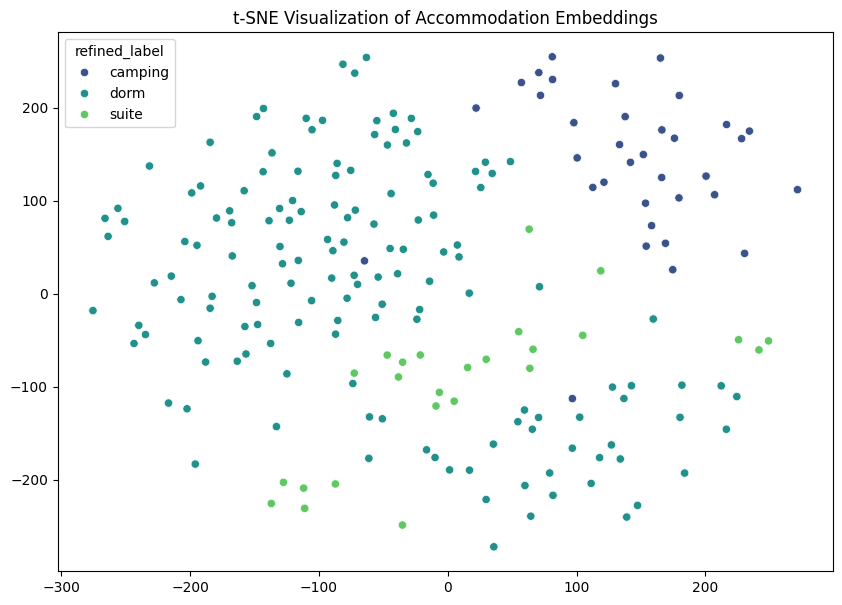

In [68]:
# perplexity is the most important hyperparameter (try between 5 and 50)
tsne = TSNE(n_components=2, perplexity=20, random_state=42, init='pca', learning_rate='auto')

# 2. Fit and transform your 384-dim embeddings into 2-dim coordinates
X_embedded = tsne.fit_transform(embeddings)

# 3. Plotting with Seaborn
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_embedded[:, 0], 
    y=X_embedded[:, 1], 
    hue=paid_only['refined_label'],  # Color by your labels (camping, dorm, etc.)
    palette='viridis',
    legend='full'
)
plt.title("t-SNE Visualization of Accommodation Embeddings")
plt.show()

Looking at this it actually makes sense to me.
- dorm has 2 different clumps. i wouldn't be surprised if this was because often dorm is defined by the use of a word like 'hostel' vs. a word like 'dorm'. dorm is like a common default - but also makes sense as most of the data points exist in dorm as this is often what my accomodation was
- suite is less of a clump and more of a line, maybe because there is more of a diversity in what helps define 'suite'. it is more of a vague description of anything that is private - from a private room, to a suite with a kitchen, to a casita
- camping is grouped pretty well. i would think this is a relatively simple grouping as its normally broken down by the words: camping, tent, hammock. its got distinctive descriptors
- further note: the camping outlier located in the dorm space: 'hostel hammock' (idx 134) which gives reason to using the probabilities in the place of the basic classification

In [69]:
# Train a model on all of the data
le = LabelEncoder()
y = le.fit_transform(paid_only['refined_label']) 
X = embeddings

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

print(f"Model trained on {len(X)} points across {len(le.classes_)} categories.")

Model trained on 328 points across 3 categories.


In [70]:
# get the probabilities for each of the days accomodations and put in a dataframe
probabilities = clf.predict_proba(X)
prob_cols = [f"prob_{label}" for label in le.classes_]
paid_only_probs = pd.DataFrame(probabilities, columns=prob_cols)

In [71]:
paid_only_probs.head()

,prob_camping,prob_dorm,prob_suite
0,0.771695,0.141598,0.086706
1,0.834801,0.103937,0.061261
2,0.834801,0.103937,0.061261
3,0.021391,0.898858,0.079751
4,0.034230,0.914635,0.051135


In [72]:
paid_only_probs.columns

Index(['prob_camping', 'prob_dorm', 'prob_suite'], dtype='str')

In [73]:
paid_only_feature = pd.concat([paid_only.reset_index(drop=True), paid_only_probs], axis=1)

Initially i thought that the feature from this would be a single feature with the classification of ```[camping, dorm, suite, unpaid]```. but rather i will be using the classification probabilities of all of the labels to get a more all around feature set

**put all the data together for accomodation**

In [74]:
paid_only_feature.head()

,date,note,cad,accomodation_type,predicted_label,confidence,refined_label,prob_camping,prob_dorm,prob_suite
0,2025-09-16,Forever resort campsite,12.63,NaN,camping,0.968440,camping,0.771695,0.141598,0.086706
1,2025-09-15,Semonkong campsite,13.38,NaN,camping,0.954754,camping,0.834801,0.103937,0.061261
2,2025-09-14,Semonkong campsite,13.38,NaN,camping,0.954754,camping,0.834801,0.103937,0.061261
3,2025-09-13,Sani pass dorm,11.15,NaN,dorm,0.980349,dorm,0.021391,0.898858,0.079751
4,2025-09-12,Mamohase Dorm,11.15,NaN,dorm,0.963414,dorm,0.034230,0.914635,0.051135


In [75]:
paid_only_feature = paid_only_feature[['date','note','refined_label','prob_camping', 'prob_dorm', 'prob_suite']].rename(columns={'refined_label':'accomodation_type'})
paid_only_feature.loc[:,'prob_unpaid'] = 0.0

In [76]:
# update the format of unpaid to match the format of paid
unpaid_only = accom[accom.accomodation_type == 'unpaid']

for col in paid_only_probs.columns:
    unpaid_only.loc[:,col] = 0.0

# make prob_unpaid the only column with a non zero prob value
unpaid_only.loc[:, 'prob_unpaid'] = 1.0    

unpaid_only.head()

,date,note,cad,accomodation_type,prob_camping,prob_dorm,prob_suite,prob_unpaid
0,2025-09-25,NaN,NaN,unpaid,0.0,0.0,0.0,1.0
1,2025-09-24,NaN,NaN,unpaid,0.0,0.0,0.0,1.0
2,2025-09-23,NaN,NaN,unpaid,0.0,0.0,0.0,1.0
3,2025-09-22,NaN,NaN,unpaid,0.0,0.0,0.0,1.0
4,2025-09-21,NaN,NaN,unpaid,0.0,0.0,0.0,1.0


In [77]:
# concat the two data frames and sort
accom_features = pd.concat([
    paid_only_feature[['date','prob_camping', 'prob_dorm', 'prob_suite','prob_unpaid']], 
    unpaid_only[['date','prob_camping', 'prob_dorm', 'prob_suite','prob_unpaid']]
]).sort_values(by='date', ascending=True)
accom_features.head()

,date,prob_camping,prob_dorm,prob_suite,prob_unpaid
327,2024-07-01,0.035924,0.907722,0.056354,0.0
326,2024-07-02,0.009769,0.976267,0.013964,0.0
325,2024-07-03,0.023994,0.935314,0.040692,0.0
324,2024-07-04,0.023994,0.935314,0.040692,0.0
323,2024-07-05,0.023994,0.935314,0.040692,0.0


## Food Feature
- can i take the notes from all of the food purchases and find something interesting for the kmeans?

## Bringing all the features together

### Dealing with the Missing Data
I only have money data from Bolivia onwards.... so what should i do with all the countries before? Accomodation is a bit more simple as I know I only stayed in dorms.

options:
- **segmented clustering**: seperate out finance inclusive/exclusive data out and cluster seperately
- proxy imputation with a phase baseline: look through the financial data I do have, and recognize what phases in this data match how i travelled in the missing months. Match the phases and then use the median from the phases to impute into the missing phase.
- Drop and document: drop this part of the dataset and focus on the months of full data
- synthetic feature generation: use a regression model to predict the values of the missing dates based on the data i have

will use segmented for the moment

In [103]:
first_financial_date = money_features.date.min()

In [104]:
# seperate out the dataset where we have the first financial data set
transport_features_no_fin = transport_features[transport_features.date < first_financial_date]
adv_features_no_fin = adv_features[adv_features.date < first_financial_date]

transport_features_fin = transport_features[transport_features.date >= first_financial_date]
adv_features_fin = adv_features[adv_features.date >= first_financial_date]

In [187]:
# bring together datasets into mass data set
df_fin_full = pd.merge(money_features, accom_features, how='outer', on='date')
df_fin_full = pd.merge(df_fin_full, transport_features_fin, how='outer', on='date')
df_fin_full = pd.merge(df_fin_full, adv_features_fin, how='outer', on='date')

df_no_fin_full = pd.merge(transport_features_no_fin, adv_features_no_fin, how='outer', on='date')

In [191]:
# fill in the nans with zeros
df_fin_full = df_fin_full.fillna(0)
df_no_fin_full = df_no_fin_full.fillna(0)

### Dropping features
- dropping due to high correlation with other features, or feature uselessness
- ```['total_expense','adventure_cost','num_unique_transports','approximate_time','activity_count']```

In [192]:
features_to_drop = ['total_expense','adventure_cost','num_unique_transports','approximate_time','activity_count']

In [193]:
df_fin = df_fin_full.drop(features_to_drop, axis=1)

In [194]:
df_no_fin = df_no_fin_full.drop(['num_unique_transports','approximate_time','activity_count'], axis=1)

### Normalizing the data
3 options:
- log scaling: for features with long tails to deal with few outliers, and stretch the low values (followed by min max)
- z-score: preserves shape of distribution, and handles outliers -- however, adds in negative values, which can complicate the algorithm, because 0 is a base knowledge that should be kept ($0 spent, 0 hrs travelled, 0 times done)
- min/max: for features with set boundaries, best for categoricals (discrete)

In [195]:
df_fin_norm = perform_normalization(df_fin)
df_no_fin_norm = perform_normalization(df_no_fin)

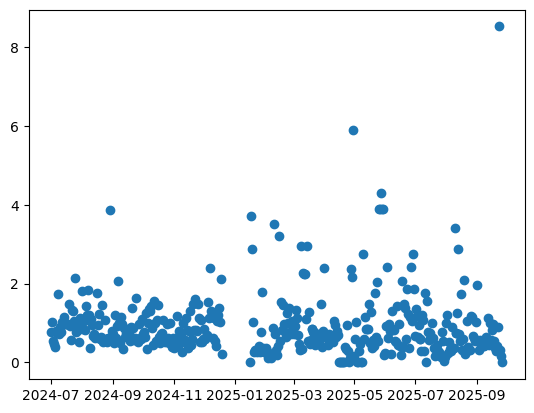

In [100]:
# checking what the data looks like to help decide on normalization types
# px.scatter(money_features, x='date', y='baseline_cost', width=400, height=400)

plt.scatter(x=df_fin.date, y=df_fin.budget_utilization)

## Saving the data

In [196]:
# final viz check
df_fin.head()

,date,transactions_per_day,budget_utilization,category_count,baseline_cost,material_purchases,experience_ratio,prob_camping,prob_dorm,prob_suite,prob_unpaid,total_num_transports,primary_transport,night_travel_ratio,hours_per_transit,activity_time,is_activity,is_tour,novelty_flag,activity_type
0,2024-07-01,4.0,0.778333,3.0,32.33,0.0,0.000000,0.035924,0.907722,0.056354,0.0,1.0,3.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0
1,2024-07-02,4.0,1.024000,4.0,23.35,0.0,0.526367,0.009769,0.976267,0.013964,0.0,2.0,2.0,0.0,2.0,4.0,0.0,1.0,1.0,2.0
2,2024-07-03,6.0,0.542500,4.0,21.70,0.0,0.151459,0.023994,0.935314,0.040692,0.0,1.0,4.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
3,2024-07-04,4.0,0.460167,2.0,27.61,0.0,0.000000,0.023994,0.935314,0.040692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-07-05,4.0,0.401167,2.0,24.07,0.0,0.000000,0.023994,0.935314,0.040692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [183]:
# final viz check
df_fin_norm.head()

,date,transactions_per_day,budget_utilization,category_count,baseline_cost,material_purchases,experience_ratio,prob_camping,prob_dorm,prob_suite,...,primary_transport_2,primary_transport_3,primary_transport_4,primary_transport_5,activity_type_0,activity_type_1,activity_type_2,activity_type_3,activity_type_4,activity_type_5
0,2024-07-01,0.307692,0.255497,0.428571,0.805959,0.0,0.000000,0.035924,0.907722,0.056354,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2024-07-02,0.307692,0.312927,0.571429,0.733803,0.0,0.526367,0.009769,0.976267,0.013964,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2024-07-03,0.461538,0.192353,0.571429,0.717675,0.0,0.151459,0.023994,0.935314,0.040692,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2024-07-04,0.307692,0.168008,0.285714,0.770861,0.0,0.000000,0.023994,0.935314,0.040692,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2024-07-05,0.307692,0.149703,0.285714,0.740501,0.0,0.000000,0.023994,0.935314,0.040692,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [198]:
# save all dataframes 
df_fin.to_csv('../data/features_financial.csv', index=False)
df_no_fin.to_csv('../data/features_no_financial.csv', index=False)

df_fin_full.to_csv('../data/features_financial_all.csv', index=False)
df_no_fin_full.to_csv('../data/features_no_financial_all.csv', index=False)

df_fin_norm.to_csv('../data/features_financial_normalized.csv', index=False)
df_no_fin_norm.to_csv('../data/features_no_financial_normalized.csv', index=False)

## Looking into the correlation between similar features

#### Money Features

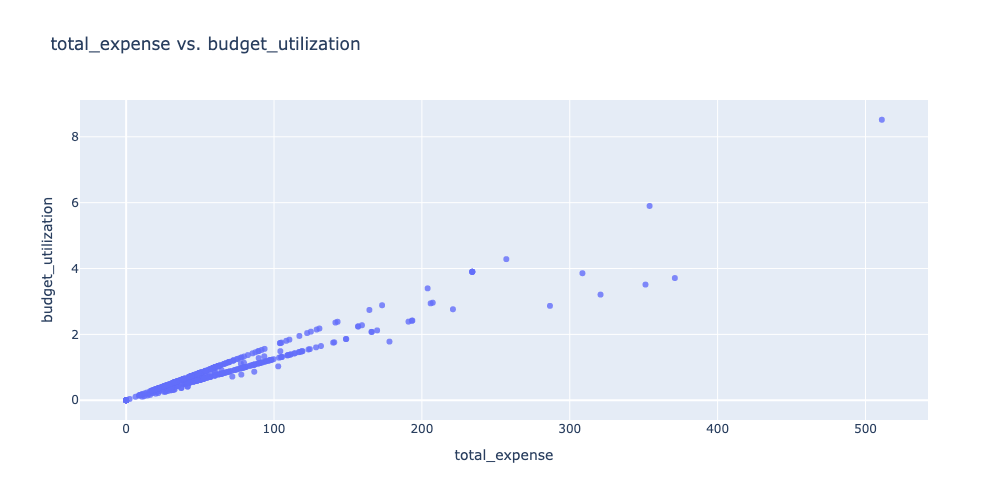

correlation coefficient: 0.96


In [135]:
corr_check(df_fin, 'total_expense', 'budget_utilization')

--> will drop total_expense and will keep budget utilization because it shows a better account of my behaviour as a moved to different places and had different budgets

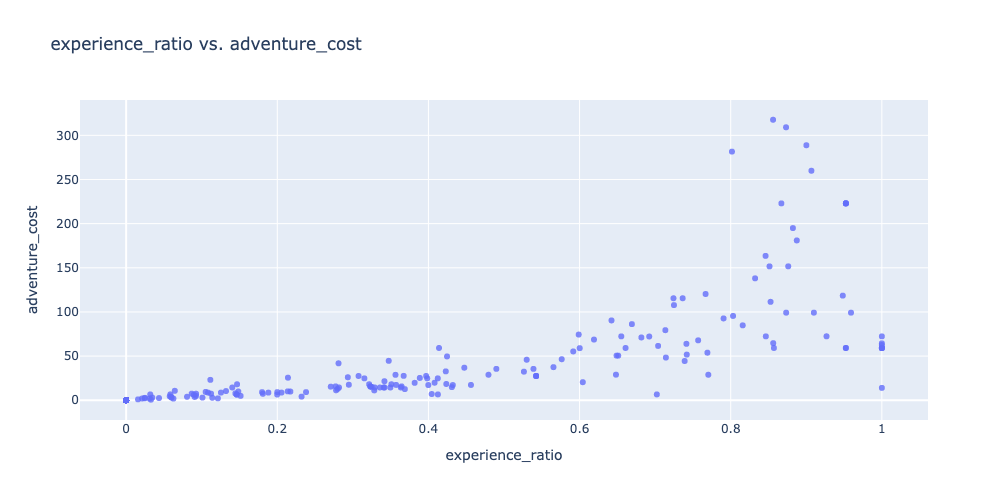

correlation coefficient: 0.78


In [136]:
corr_check(df_fin, 'experience_ratio', 'adventure_cost')

--> will drop adventure_cost and keep experience_ratio as it gives more information about the spending behaviour of the adventure and removes how inflation of prices across different countries can affect total cost

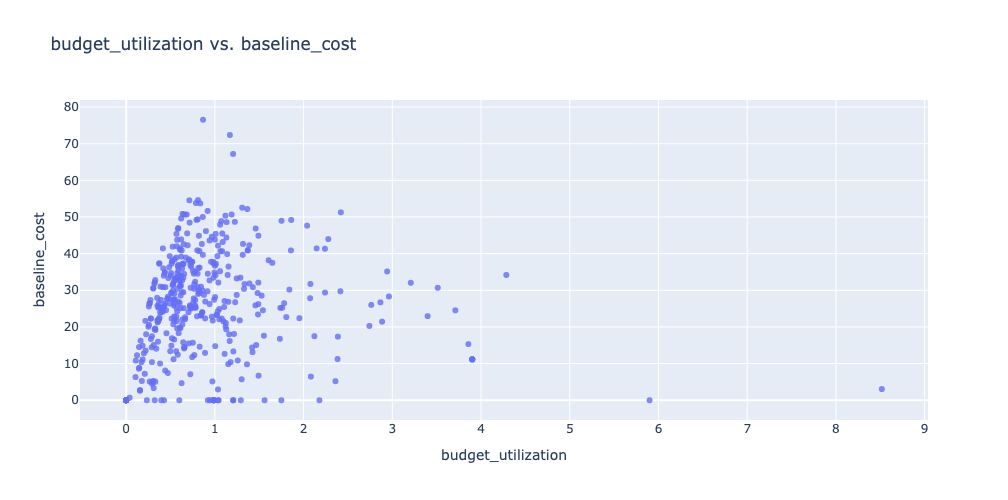

correlation coefficient: 0.04


In [125]:
corr_check(df_fin, 'budget_utilization', 'baseline_cost')

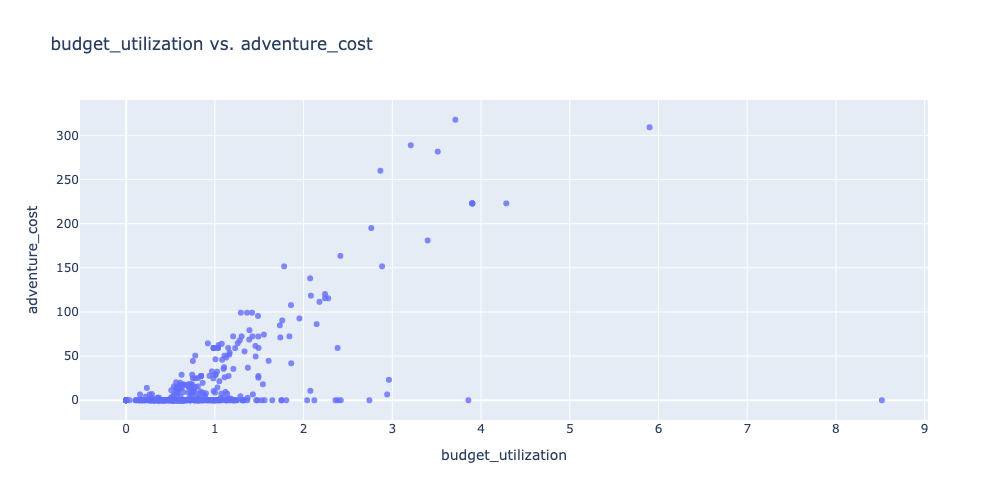

correlation coefficient: 0.68


In [126]:
corr_check(df_fin, 'budget_utilization', 'adventure_cost')

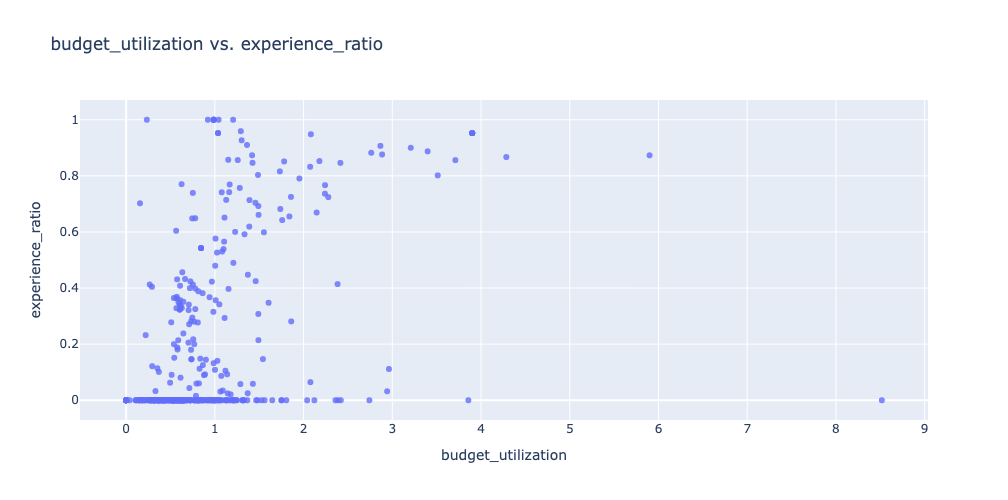

correlation coefficient: 0.46


In [137]:
corr_check(df_fin, 'budget_utilization', 'experience_ratio')

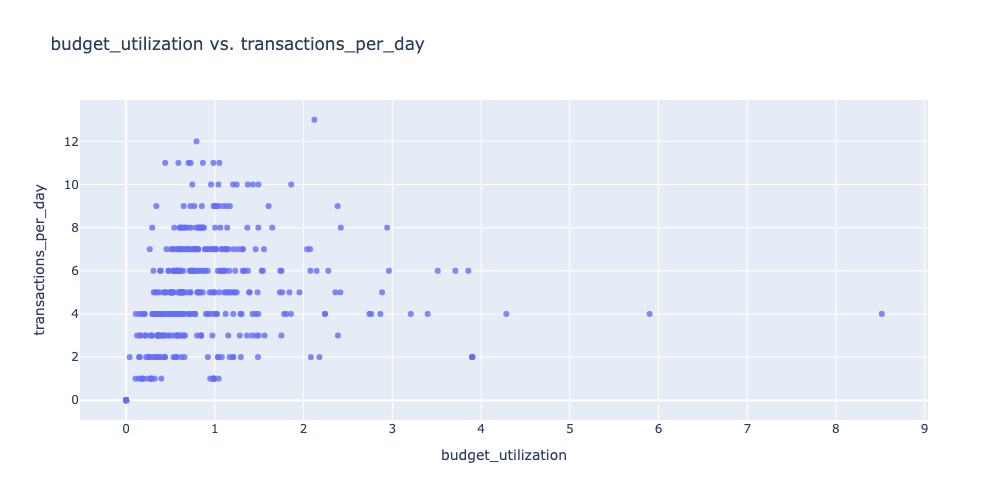

correlation coefficient: 0.15


In [131]:
corr_check(df_fin, 'budget_utilization', 'transactions_per_day')

#### Transport Features

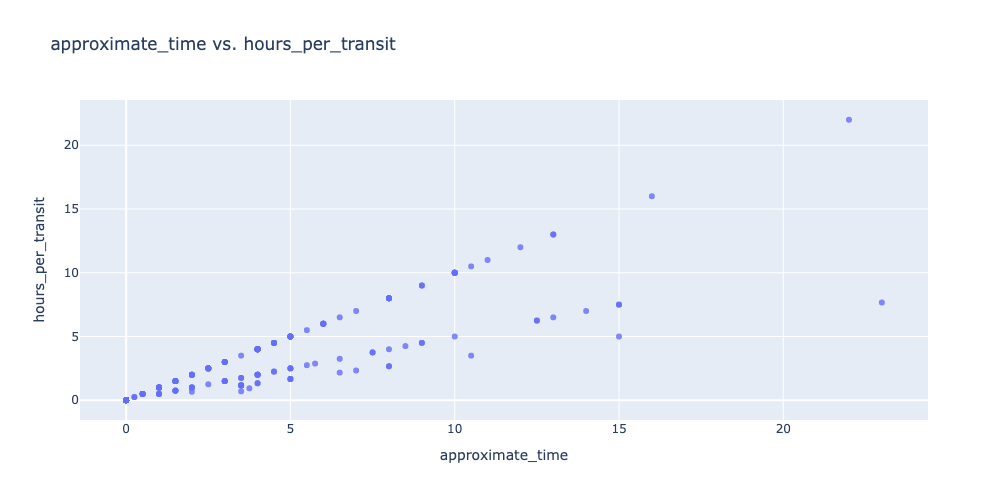

correlation coefficient: 0.91


In [149]:
corr_check(df_fin, 'approximate_time', 'hours_per_transit')

--> drop approximate_time, as its just showing the sum and keep hours_per_transit because its showing intensity of the transit day, together with total_num_transports shows how hectic the day is

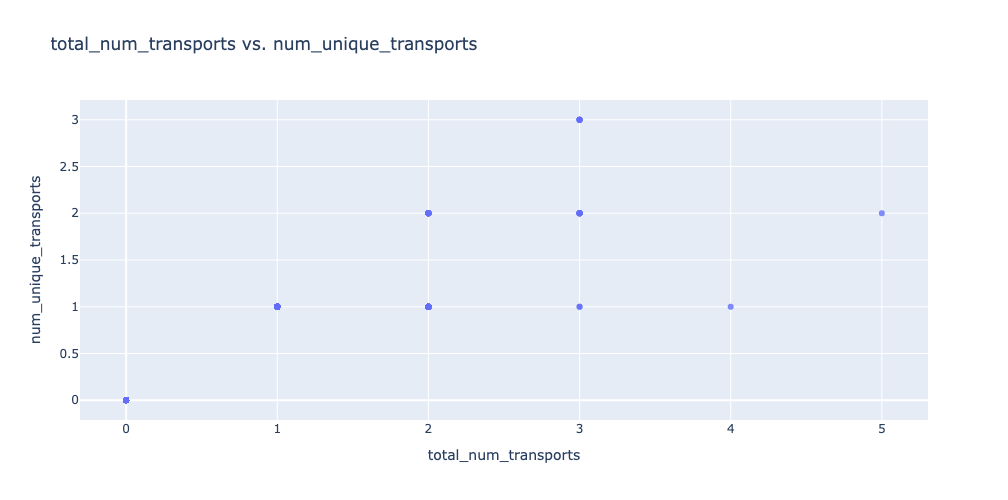

correlation coefficient: 0.92


In [146]:
corr_check(df_fin, 'total_num_transports', 'num_unique_transports')

--> keep 'total_num_transports' and get rid of 'num_unique_transports' because we have a categorical column related to the tyopes of transport, and this column does not introduce a lot of variance or interesting info into our data

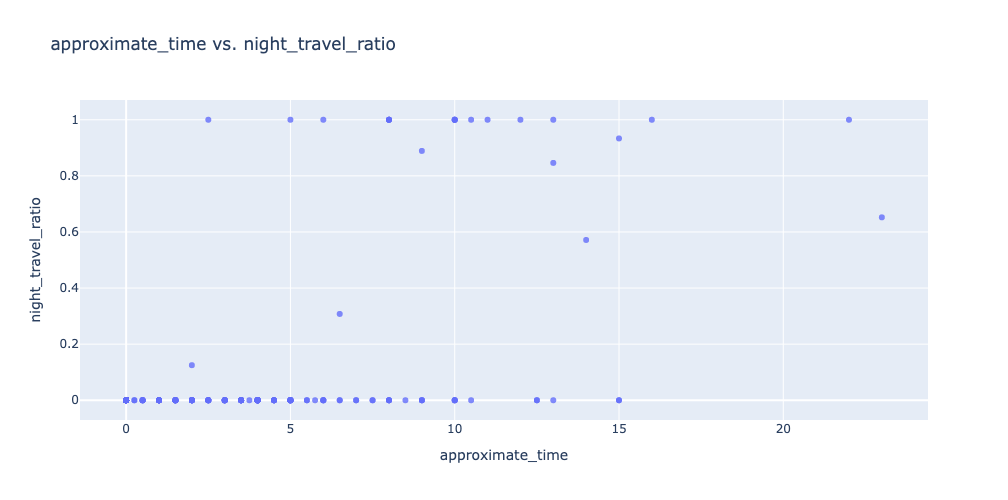

correlation coefficient: 0.59


In [148]:
corr_check(df_fin, 'approximate_time', 'night_travel_ratio')

#### Activity Features

In [139]:
df_fin.columns

Index(['date', 'total_expense', 'transactions_per_day', 'budget_utilization',
       'category_count', 'baseline_cost', 'adventure_cost',
       'material_purchases', 'experience_ratio', 'prob_camping', 'prob_dorm',
       'prob_suite', 'prob_unpaid', 'approximate_time', 'total_num_transports',
       'num_unique_transports', 'primary_transport', 'night_travel_ratio',
       'hours_per_transit', 'activity_time', 'is_activity', 'is_tour',
       'activity_count', 'novelty_flag', 'activity_type'],
      dtype='str')

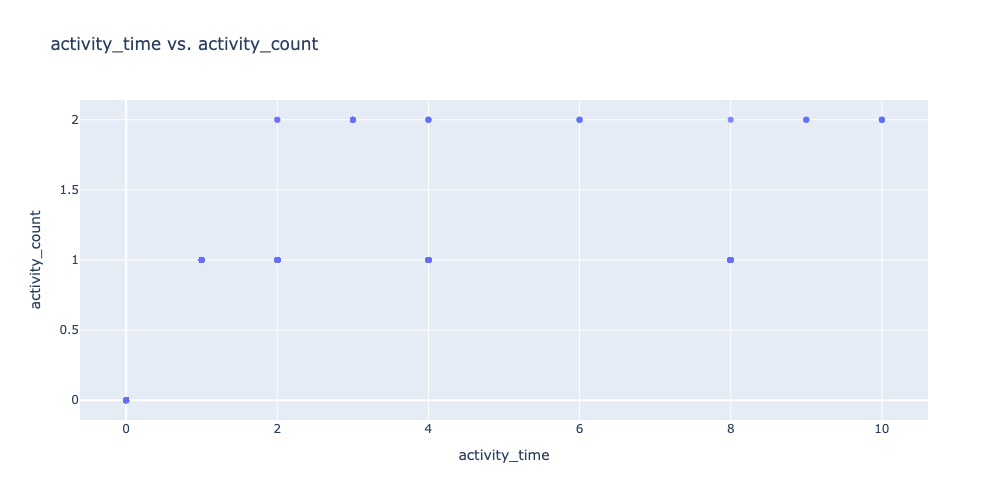

correlation coefficient: 0.75


In [150]:
corr_check(df_fin, 'activity_time', 'activity_count')

In [151]:
df_fin.activity_count.value_counts()

activity_count
0.0    207
1.0    201
2.0     21
Name: count, dtype: int64

--> i think im going to drop activity_count for now as there is a not a lot of variation adn its not adding information to a day. I might consider making a time_per_activity in the future, but for right now, i dont know if it adds much, because it would essentially be halfing the time spent in a day to 2 activities (in the case that there are 2). and while that works for some day2 with 2 activies, it doesnt for others.